In [ ]:
# Import ionique along with the other necessary libraries

import ionique.core as ct
from ionique.io import OPTReader
from ionique.parsers import SpeedyStatSplit
from ionique.parsers import AutoSquareParser
import ionique.datatypes as dt
import os
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from ionique.utils import Trimmer, Filter##, extract_features



## Run the function for generating a trace image for each file that will be loaded.

### This is to visualize and decide whether you to continue analyzing the file.

In [3]:
def export_snapshots(datafiles:list,output_directory,filter, downsample,i_ylim=None,v_ylim=None):
    try:
        os.mkdir(output_directory)
    except:
        pass

    plt.ioff()
    plt.close('all')
    for file in datafiles: # adjust number of infiles to be processed
        metadata, current, voltage = OPTReader(file, voltage_compress=True, downsample=downsample,prefilter=filter)
        sampling_frequency = metadata['Sampling frequency (SR)']
        time = np.linspace(0, len(current) / (sampling_frequency/downsample), num=len(current))
        voltage_ = np.zeros(len(current))
        for (start, end), value in voltage:
            voltage_[start:end] = value
            
        # adjust plot size here if needed 
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax1.plot(time, current, lw=0.3, c='k', label='Current')
        ax2 = ax1.twinx()
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Current (nA)', color='k')
        ax1.tick_params(axis='y', labelcolor='k')
        ax2.plot(time, voltage_, lw=0.5, c='r', label='Voltage')
        ax2.set_ylabel('Voltage (mV)', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        file_name = metadata["HeaderFile"].split("/")[-1]
        plt.title(f"I and V plot for \n{file_name}")
        if i_ylim:
            ax1.set_ylim(i_ylim)
        if v_ylim:
            ax2.set_ylim(v_ylim)
        
        fig.savefig(os.path.join(output_directory, os.path.splitext(os.path.split(metadata["HeaderFile"])[-1])[0]+".png"), bbox_inches="tight")
        plt.close(fig)
        del current,voltage_,voltage,metadata,time


def from_snapshots(directory,datafiles_to_match,pattern="*.png"):
    selected_files=[]
    pngs=glob.glob(directory+pattern,recursive=True)
    for file in datafiles_to_match:
        for pngname in pngs:
            if os.path.splitext(os.path.split(pngname)[1])[0] in file:
                selected_files.append(file)
    return selected_files


## Specify the directory containing the experimental files.
### Here we are loading data containing reverse transport events of MBP-D10 through WT CytK at a 15 nM concentration.   

In [ ]:
file_pattern='<directory_to_experiment_files_here>'

datafiles=glob.glob(file_pattern,recursive=True) # Replace the path here

print(f"Found {len(datafiles)} files \n")
print(*datafiles , sep='\n')

## Initialize the digital low-pass filter that will be applied onto the data.

In [7]:
# Initialize Filter
cutoff_frequency = 25000 #25 kHz cutoff frequency
filter_type = "lowpass"
filter_method = "bessel"
order = 2
bidirectional = True
sampling_frequency = 250000 #250 kHz DAQ sampling frequency
downsample = 5 #downsampling after filtering

filt = Filter(
    cutoff_frequency=cutoff_frequency,
    filter_type='lowpass',
    filter_method = filter_method,
    bidirectional=bidirectional,
    sampling_frequency=sampling_frequency
)
trimmer=Trimmer(samples_to_remove=2500) #Number of samples removed after a change in the applied voltage (to remove capacitive spikes) 


## Let's now export the trace for each file as an image.

In [ ]:
#Make a folder called "snapshots"
export_snapshots(datafiles,output_directory="snapshots",filter=filt,downsample=downsample,i_ylim=(-1,1))

## Check the file image and for each one that you would like to analyze.
### Move each .png file into the "selected" subfolder for the files you would like to analyze.

In [ ]:
#Make a folder called "selected" in "snapshots"
datafiles=glob.glob(file_pattern,recursive=True) # Replace the path here
selected_datafiles=from_snapshots("snapshots/selected/",datafiles)

print(*selected_datafiles,sep='\n')

MBP_D10\030325\15nM\B030325_918--204056.opt
MBP_D10\030325\15nM\B030325_918--205144.opt


## Next, let's load the selected data into ionique and remove the capacitive spikes from each trace.

In [ ]:
sfm = dt.SessionFileManager()
sfm.clear_children()
dfs={}

for datafile in selected_datafiles[:]: 
    metadata, current, voltage = OPTReader(datafile, voltage_compress=True, downsample=downsample, prefilter=filt)
    directory=os.path.split(datafile)[0].split(os.path.sep)
    sample_type=directory[0]
    concentration=float(directory[2].split("n")[0])*1e-9

    trace_file = dt.TraceFile(
        current=current,
        voltage=voltage, 
        parent=sfm,
        metadata=metadata,
        unique_features={
            "sampling_freq": metadata["eff_sampling_freq"],
            "eff_sampling_freq": metadata["eff_sampling_freq"],
            "sample_type":sample_type,
            "concentration":concentration
        }
    )
    trimmer(trace_file)

## Let's now load one of ionique's event parsing algorithms and extract translocation events from each trace.

In [ ]:
from importlib import reload
import ionique.parsers
reload (ionique.parsers)
from ionique.parsers import AutoSquareParser

In [ ]:
for trace_file in sfm.children:
    event_parser = AutoSquareParser(threshold_baseline=0.7,expected_conductance=2,conductance_tolerance=1.15,wrap_padding=50,rules=[lambda event:event.duration>4]) #all analysis with this condition
    trace_file.parse(parser=event_parser,at_child_rank="vstepgap",newrank="event")
   

## Run this plotting function to visualize events (green) that were parsed from each trace (black) along with the corresponding voltage (red).  

In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot(seg, at_rank, downsample=1, ax=None, ax2=None, time_range=[], lw_baseline=0.3,
         lw_event=0.3, lw_voltage=0.5, trans_baseline=0.33,trans_event=1,show_voltage=True, raster=False, figsize=(5, 5), color='k', fontsize=15):
    """ Plotting trace file for inspecting current and voltage. """
    
    if not ax or not ax2:
        fig = plt.figure(figsize=figsize, dpi=120)
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
        ax = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1], sharex=ax)
        
        ax.set_ylabel("Current (nA)", fontsize=fontsize)
        ax2.set_ylabel("Voltage (V)", color='r', fontsize=fontsize)
        ax2.set_xlabel("Time (s)", fontsize=fontsize)

        ax.tick_params(axis='x', direction='in', length=5, width=1, labelbottom=False)
        ax.tick_params(axis='y', direction='in', length=5, width=1)

        ax2.tick_params(axis='x', direction='in', length=5, width=1)
        ax2.tick_params(axis='y', direction='in', length=5, width=1, colors='r')
    else:
        fig = ax.get_figure()

    if at_rank:
        for idx, step in enumerate(seg.traverse_to_rank(at_rank)):
            if time_range and (step.time[0] < time_range[0] or step.time[-1] > time_range[1]):
                continue
            v = step.get_feature("voltage")
            ax.plot(step.time[::downsample], step.current[::downsample], c=color, lw=lw_event, alpha=trans_event, rasterized=raster)
            ax2.plot((step.time[0], step.time[-1]), [v]*2, c='r', rasterized=raster)
    else:
        index_1 = np.where(seg.time > time_range[0])[0][0]
        index_2 = np.where(seg.time < time_range[-1])[0][-1]
        
        ax.plot(seg.time[index_1:index_2:downsample],
                seg.current[index_1:index_2:downsample], c=color, lw=lw_event, alpha=trans_event, rasterized=raster)

        if show_voltage:
            for idx, step in enumerate(seg.traverse_to_rank('vstepgap')):
                if time_range and (step.time[0] < time_range[0] or step.time[-1] > time_range[1]):
                    continue
                v = step.get_feature("voltage")
                ax2.plot((step.time[0], step.time[-1]), [v]*2, lw=lw_voltage, c='r', rasterized=raster)

    return fig, (ax, ax2)


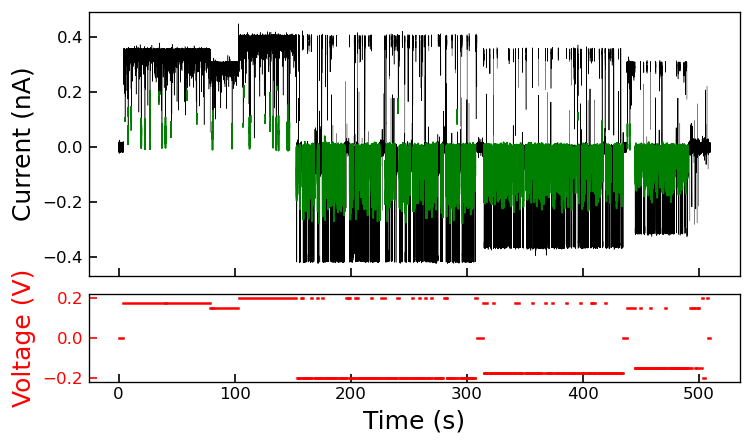

In [ ]:
#Example plot of trace after event extraction. The analyte here is MBP-D10 and these translocation events through WT-CytK (forward + reverse transport)
##%matplotlib qt
%matplotlib inline
for trace_file in sfm.children[0:1]: #If you have multiple files loaded, then you are plotting the first file with 'sfm.children[0:1]'
    fig,(ax1,ax2)=plot(trace_file,at_rank="vstepgap",downsample=1,figsize=(7,4))
    plot(trace_file,at_rank="event",downsample=1,ax=ax1,ax2=ax2,trans_baseline=0.5,trans_event=1,lw_baseline=0.1,lw_event=1,color='g',figsize=(7,4))

## Next, let's take the detected events along with their corresponding features and store them into a structured DataFrame for easier downstream analysis.

In [ ]:
from ionique.utils import extract_features

dfs={}
for trace_file in sfm.children:
    df=extract_features(trace_file, bottom_rank="event",
                      extractions=['mean', 'std','frac', 'duration', 'current', 'wrap', 'start'],
                      add_ons={"sample_type": trace_file.unique_features['sample_type'],
                               "filename": trace_file.metadata["HeaderFile"],#}
                               "concentration": trace_file.unique_features["concentration"]},

                      lambdas={ "baseline": lambda event: np.abs(event.unique_features["baseline"])*(-1 if event.get_feature("voltage")<0.00001 else 1),
                                "Voltage": lambda event: int(1000 * round(float(event.get_feature("voltage")), 3)),
                               "baseline_conductance":lambda event:np.abs(event.unique_features["baseline"]/event.get_feature("voltage")),
                               "start_time": lambda event: event.time[0],
                               "parent_start_time":lambda event: event.parent.time[0]
                               })
    destination=f"{trace_file.unique_features['sample_type']}-{trace_file.unique_features['concentration']*1e9:.1f}nM-{os.path.splitext(os.path.split(trace_file.metadata["HeaderFile"])[-1])[0]}.pkl"
    dfs[destination]=df    



In [ ]:
masterdf=pd.concat([_df for _df in dfs.values()],ignore_index=True)
masterdf["log_duration"] = np.log10(masterdf["duration"]) #Add log duration to the dataframe
# masterdf.to_pickle("<path/to/pickled/df/.pkl>") #uncomment this to save the pickled dataframe 